# Oppgave 1: Modellering av et meslingutbrudd

## Oppgave 1a: Markovkjede og overgangsmatrise
Prosessen $\{X_n\}$ er en Markovkjede fordi tilstanden til personen neste dag bare avhenger av hvilken tilstand personen er i i dag, og ikke av tidligere tilstander.

Vi har tre tilstander:

- $S$: mottakelig for smitte
- $I$: smittet
- $R$: frisk og immun

Disse tilsvarer henholdsvis tilstandene $0$, $1$ og $2$.

Hvis personen er i $S$, blir personen smittet neste dag med sannsynlighet $\beta$, og forblir i $S$ med sannsynlighet $1-\beta$.

Hvis personen er i $I$, blir personen frisk og immun med sannsynlighet $\gamma$, og forblir smittet med sannsynlighet $1-\gamma$.

Hvis personen er i $R$, mister personen immuniteten og går tilbake til $S$ med sannsynlighet $\alpha$, og forblir i $R$ med sannsynlighet $1-\alpha$.

Dermed blir overgangsmatrisen

$$
P =
\begin{pmatrix}
1-\beta & \beta & 0 \\
0 & 1-\gamma & \gamma \\
\alpha & 0 & 1-\alpha
\end{pmatrix}.
$$

Her er $\beta$ sannsynligheten for å gå fra $S$ til $I$, $\gamma$ sannsynligheten for å gå fra $I$ til $R$, og $\alpha$ sannsynligheten for å gå fra $R$ til $S$.

## Oppgave 1b: Grensefordeling og forventet antall dager



For $\beta=0.01$, $\gamma=0.10$ og $\alpha=0.005$ får vi overgangsmatrisen

$$
P=
\begin{pmatrix}
0.99 & 0.01 & 0 \\
0 & 0.90 & 0.10 \\
0.005 & 0 & 0.995
\end{pmatrix}.
$$

Markovkjeden er irreducibel siden det er mulig å komme fra enhver tilstand til enhver annen tilstand gjennom kjeden

$$
S \to I \to R \to S.
$$

Den er også aperiodisk, siden hver tilstand har positiv sannsynlighet for å bli værende i samme tilstand. Dermed har den en unik limiting distribution.

La den stasjonære fordelingen være

$$
\pi=(\pi_S,\pi_I,\pi_R).
$$

Vi løser

$$
\pi P=\pi
$$

sammen med

$$
\pi_S+\pi_I+\pi_R=1.
$$

Fra ligningene får vi

$$
0.01\pi_S=0.10\pi_I
$$

slik at

$$
\pi_I=0.1\pi_S.
$$

Videre får vi

$$
0.10\pi_I=0.005\pi_R,
$$

og dermed

$$
\pi_R=20\pi_I=2\pi_S.
$$

Ved å bruke

$$
\pi_S+\pi_I+\pi_R=1
$$

får vi

$$
\pi_S+0.1\pi_S+2\pi_S=1,
$$

så

$$
\pi_S=\frac{1}{3.1}\approx0.3226.
$$

Dermed blir

$$
\pi_I\approx0.0323,
\qquad
\pi_R\approx0.6452.
$$

Den langsiktige andelen tid i hver tilstand er derfor omtrent

$$
(\pi_S,\pi_I,\pi_R)
=
(0.3226,0.0323,0.6452).
$$

Siden ett år har 365 dager, blir det gjennomsnittlige antallet dager per år

$$
365\pi_S\approx117.7,
$$

$$
365\pi_I\approx11.8,
$$

$$
365\pi_R\approx235.5.
$$

Altså vil personen i det lange løp i gjennomsnitt være omtrent 118 dager mottakelig, 12 dager smittet og 235 dager frisk og immun per år.

## Oppgave 1c: Simulering og konfidensintervaller

In [1]:
import numpy as np
from scipy.stats import t

P = np.array([
    [0.990, 0.010, 0.000],  # S
    [0.000, 0.900, 0.100],  # I
    [0.005, 0.000, 0.995],  # R
])

STATE_NAMES = ["S", "I", "R"]
DAYS_PER_YEAR = 365
N_YEARS = 20
N_ANALYSIS_YEARS = 10
N_TIME_STEPS = N_YEARS * DAYS_PER_YEAR
N_ANALYSIS_STEPS = N_ANALYSIS_YEARS * DAYS_PER_YEAR
N_RUNS = 30
SEED = 2026


def simulate_chain(transition_matrix, n_time_steps, rng, initial_state=0):

    states = np.empty(n_time_steps, dtype=int)
    states[0] = initial_state

    for n in range(1, n_time_steps):
        states[n] = rng.choice(
            transition_matrix.shape[0],
            p=transition_matrix[states[n - 1]],
        )

    return states


rng = np.random.default_rng(SEED)
estimates = np.empty((N_RUNS, len(STATE_NAMES)))

for run in range(N_RUNS):
    states = simulate_chain(P, N_TIME_STEPS, rng)
    last_10_years = states[-N_ANALYSIS_STEPS:]
    counts = np.bincount(last_10_years, minlength=len(STATE_NAMES))
    estimates[run] = counts / N_ANALYSIS_YEARS


assert np.allclose(estimates.sum(axis=1), DAYS_PER_YEAR)

means = estimates.mean(axis=0)
standard_errors = estimates.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
critical_value = t.ppf(0.975, df=N_RUNS - 1)
lower = means - critical_value * standard_errors
upper = means + critical_value * standard_errors

exact_days = DAYS_PER_YEAR * np.array([10 / 31, 1 / 31, 20 / 31])
compatible = (lower <= exact_days) & (exact_days <= upper)

print(f"{'Tilstand':<8} {'Estimat':>10} {'95 % KI':>20} {'Eksakt':>10} {'Kompatibel':>12}")
for state, mean, low, high, exact, agrees in zip(
    STATE_NAMES, means, lower, upper, exact_days, compatible
):
    interval = f"[{low:.1f}, {high:.1f}]"
    print(f"{state:<8} {mean:>10.1f} {interval:>20} {exact:>10.1f} {str(agrees):>12}")

Tilstand    Estimat              95 % KI     Eksakt   Kompatibel
S             119.1       [107.2, 131.0]      117.7         True
I              12.6         [11.0, 14.1]       11.8         True
R             233.3       [221.0, 245.6]      235.5         True


### Metode og resultater

Markovkjeden ble simulert i 7300 tidssteg, tilsvarende 20 år. 
Kjeden startet i tilstand $S$, og vi brukte frøet 2026 for å gjøre resultatene reproduserbare. For hver simulering brukte vi kun de siste 
3650 tidsstegene, tilsvarende de siste 10 årene, til å estimere den 
langsiktige andelen tid i tilstandene $S$, $I$ og $R$.

For hver tilstand beregnet vi estimert antall dager per år ved

$$
\hat d_j = 365\frac{N_j}{3650},
$$

der $N_j$ er antall dager tilbrakt i tilstand $j$ i løpet av de siste 
10 årene.

Denne simuleringen ble gjentatt 30 uavhengige ganger. For hver tilstand 
fikk vi dermed 30 estimater. Vi beregnet gjennomsnittet $\bar d_j$ og 
utvalgsstandardavviket $s_j$, og brukte et tilnærmet 95\% 
konfidensintervall

$$
\bar d_j \pm t_{0.975,29}\frac{s_j}{\sqrt{30}}.
$$

Den aktuelle kjøringen ga følgende resultater:

| Tilstand | Estimert gjennomsnitt (dager per år) | 95\% konfidensintervall | Eksakt verdi fra 1b |
|:--:|--:|:--:|--:|
| $S$ | 119.1 | $[107.2, 131.0]$ | 117.7 |
| $I$ | 12.6 | $[11.0, 14.1]$ | 11.8 |
| $R$ | 233.3 | $[221.0, 245.6]$ | 235.5 |

De eksakte verdiene fra 1b ligger innenfor de respektive 95\% konfidensintervallene. Resultatene fra simuleringen er derfor kompatible med håndberegningene. At de estimerte gjennomsnittene ikke er helt like de eksakte verdiene, er forventet fordi simuleringene har endelig lengde og dermed inneholder tilfeldig variasjon. Konfidensintervallene uttrykker usikkerheten i de estimerte gjennomsnittene.

### Oppgave 1d

Vi har prosessen

$$
Y_n=(S_n,I_n,R_n),
$$

der $S_n$, $I_n$ og $R_n$ er antall mottakelige, smittede og immune personer ved tidspunkt $n$.

Gitt tilstanden $Y_n=(S_n,I_n,R_n)$ vet vi hvor mange personer som befinner seg i hver gruppe. I modellen endrer individene tilstand uavhengig av hverandre, gitt dagens tilstand. Derfor tror vi at antall personer som skifter tilstand beskrives med binomiske fordelinger.

Antall nye smittede er

$$
B_{SI}\sim \mathrm{Bin}(S_n,\beta_n),
$$

der

$$
\beta_n=0.5\frac{I_n}{N}.
$$

Dette er binomisk fordi vi har $S_n$ mottakelige personer, og hver av dem blir smittet med samme sannsynlighet $\beta_n$.

På samme måte er antall smittede som blir friske og immune

$$
B_{IR}\sim \mathrm{Bin}(I_n,\gamma),
$$

og antall immune som mister immuniteten er

$$
B_{RS}\sim \mathrm{Bin}(R_n,\alpha).
$$

Dermed kan neste tilstand skrives som

$$
S_{n+1}=S_n-B_{SI}+B_{RS},
$$

$$
I_{n+1}=I_n-B_{IR}+B_{SI},
$$

$$
R_{n+1}=R_n-B_{RS}+B_{IR}.
$$

Siden fordelingen til disse overgangene bare avhenger av
$S_n$, $I_n$ og $R_n$, og ikke av tidligere tilstander, er
$\{Y_n\}$ en Markovkjede.

Prosessen

$$
Z_n=(S_n,I_n)
$$

er også en Markovkjede. Dette skyldes at populasjonsstørrelsen $N$ er konstant, slik at

$$
R_n=N-S_n-I_n.
$$

Når $S_n$ og $I_n$ er kjent, kan vi derfor også finne $R_n$, og vi har dermed all informasjonen som trengs for å bestemme fordelingen til neste steg.

Prosessen $\{I_n\}$ alene er derimot ikke en Markovkjede. Antall smittede ved neste tidspunkt avhenger både av hvor mange som allerede er smittet og hvor mange mottakelige personer som finnes. Vi kan for eksempel skrive

$$
I_{n+1}=I_n-B_{IR}+B_{SI},
$$

der

$$
B_{IR}\sim\mathrm{Bin}(I_n,\gamma)
$$

og

$$
B_{SI}\sim\mathrm{Bin}(S_n,\beta_n).
$$

Selv om $I_n$ er kjent, kjenner vi ikke $S_n$. To situasjoner kan derfor ha samme verdi av $I_n$, men forskjellige verdier av $S_n$, og dermed forskjellige fordelinger for $I_{n+1}$. Derfor inneholder $I_n$ alene ikke nok informasjon til å oppfylle Markov-egenskapen.

## Oppgave 1e: Simulering av populasjonsmodellen

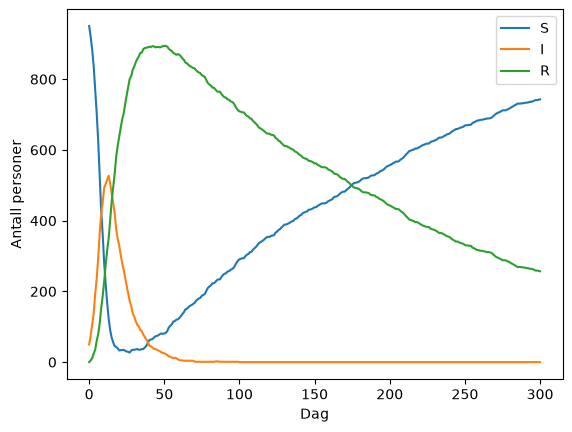

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
gamma = 0.10
alpha = 0.005
n_steps = 300

S = np.zeros(n_steps + 1, dtype=int)
I = np.zeros(n_steps + 1, dtype=int)
R = np.zeros(n_steps + 1, dtype=int)

# Starttilstand
S[0] = 950
I[0] = 50
R[0] = 0

for n in range(n_steps):

    beta = 0.5 * I[n] / N

    new_infected = np.random.binomial(S[n], beta)
    new_recovered = np.random.binomial(I[n], gamma)
    lost_immunity = np.random.binomial(R[n], alpha)

    S[n + 1] = S[n] - new_infected + lost_immunity
    I[n + 1] = I[n] + new_infected - new_recovered
    R[n + 1] = R[n] + new_recovered - lost_immunity
    days = np.arange(n_steps + 1)

plt.plot(days, S, label="S")
plt.plot(days, I, label="I")
plt.plot(days, R, label="R")

plt.xlabel("Dag")
plt.ylabel("Antall personer")
plt.legend()
plt.show()

I tidsintervallet $0$--$50$ ser vi et raskt sykdomsutbrudd. Antallet smittede $I_n$ øker kraftig i starten, samtidig som antallet mottakelige $S_n$ faller raskt. Dette skjer fordi det i starten er mange mottakelige personer, og smittesannsynligheten

$$
\beta_n = 0.5\frac{I_n}{N}
$$

øker når antallet smittede øker. Dermed kan smitten spre seg svært raskt.

Etter omtrent 50 dager er situasjonen annerledes. De fleste har da vært smittet og gått over til den immune tilstanden $R_n$, mens antallet smittede har falt til et svært lavt nivå. Når $I_n$ blir liten, blir også $\beta_n$ liten, og det kommer derfor få nye smittede.

Samtidig mister noen av de immune personene immuniteten med sannsynlighet $\alpha=0.005$ og går tilbake til $S$. Dette forklarer hvorfor $S_n$ gradvis øker og $R_n$ gradvis synker i perioden $50$--$300$.

Forskjellen mellom de to periodene skyldes derfor at $0$--$50$ er en rask utbruddsfase, mens $50$--$300$ hovedsakelig er en periode der smitten nesten har forsvunnet og immune personer gradvis blir mottakelige igjen.

## Oppgave 1f: Maksimalt antall smittede

In [3]:
import numpy as np
from scipy.stats import t

# Parametre
N = 1000
gamma = 0.10
alpha = 0.005

n_steps = 300
n_simulations = 1000
rng = np.random.default_rng(2026)


max_infected = np.zeros(n_simulations, dtype=int)
peak_times = np.zeros(n_simulations, dtype=int)

for sim in range(n_simulations):


    S = np.zeros(n_steps + 1, dtype=int)
    I = np.zeros(n_steps + 1, dtype=int)
    R = np.zeros(n_steps + 1, dtype=int)


    S[0] = 950
    I[0] = 50
    R[0] = 0


    for n in range(n_steps):

        beta = 0.5 * I[n] / N


        new_infected = rng.binomial(S[n], beta)
        new_recovered = rng.binomial(I[n], gamma)
        lost_immunity = rng.binomial(R[n], alpha)


        S[n + 1] = S[n] - new_infected + lost_immunity
        I[n + 1] = I[n] + new_infected - new_recovered
        R[n + 1] = R[n] + new_recovered - lost_immunity

    
    max_infected[sim] = np.max(I)


    peak_times[sim] = np.argmax(I)



mean_max = np.mean(max_infected)
mean_peak_time = np.mean(peak_times)


se_max = np.std(max_infected, ddof=1) / np.sqrt(n_simulations)
se_time = np.std(peak_times, ddof=1) / np.sqrt(n_simulations)


t_critical = t.ppf(0.975, df=n_simulations - 1)


ci_max = (
    mean_max - t_critical * se_max,
    mean_max + t_critical * se_max
)

ci_time = (
    mean_peak_time - t_critical * se_time,
    mean_peak_time + t_critical * se_time
)


print(f"Forventet maksimalt antall smittede: {mean_max:.2f}")
print(f"95 % CI: ({ci_max[0]:.2f}, {ci_max[1]:.2f})")

print()

print(f"Forventet tidspunkt for smittetoppen: {mean_peak_time:.2f} dager")
print(f"95 % CI: ({ci_time[0]:.2f}, {ci_time[1]:.2f})")

Forventet maksimalt antall smittede: 523.72
95 % CI: (522.46, 524.97)

Forventet tidspunkt for smittetoppen: 11.86 dager
95 % CI: (11.81, 11.91)


### Oppgave 1f

For å undersøke hvor alvorlig sykdomsutbruddet kan bli, simulerte vi modellen
1000 uavhengige ganger for tidsstegene $n=0,\ldots,300$. Vi brukte
tilfeldig frø 2026 slik at resultatene kan reproduseres.

For hver simulering registrerte vi det høyeste antallet smittede,

$$
M=\max\{I_0,I_1,\ldots,I_{300}\},
$$

samt det første tidspunktet hvor dette maksimumet ble nådd,

$$
T=\min\left\{\arg\max_{n\leq300} I_n\right\}.
$$

Forventningsverdiene ble estimert ved å ta gjennomsnittet av de 1000
simulerte verdiene. Det vil si at

$$
E[M]\approx \frac{1}{1000}\sum_{j=1}^{1000}M_j
$$

og

$$
E[T]\approx \frac{1}{1000}\sum_{j=1}^{1000}T_j.
$$

For begge størrelsene beregnet vi også et tilnærmet 95\%
konfidensintervall ved

$$
\bar{x}\pm t_{0.975,999}\frac{s}{\sqrt{1000}},
$$

der $\bar{x}$ er gjennomsnittet av de 1000 simuleringene og $s$ er
utvalgsstandardavviket.

Det estimerte forventede maksimale antallet smittede var
$523.72$, med et 95\% konfidensintervall på $(522.46,524.97)$.

Det estimerte forventede tidspunktet for smittetoppen var
$11.86$ dager, med et 95\% konfidensintervall på $(11.81,11.91)$.

Resultatene viser at mer enn halvparten av befolkningen forventes å være
smittet samtidig ved toppen, og at toppen forventes allerede etter omtrent
12 dager. Modellen beskriver derfor et raskt og alvorlig utbrudd som kan gi
stor belastning på kort tid.

De smale konfidensintervallene viser at de to forventningsverdiene er
estimert med liten Monte Carlo-usikkerhet. Intervallene beskriver usikkerheten
i de estimerte forventningsverdiene, ikke variasjonen i maksimum og topptid
mellom enkeltutbrudd.

## Oppgave 1g: Vaksinasjon

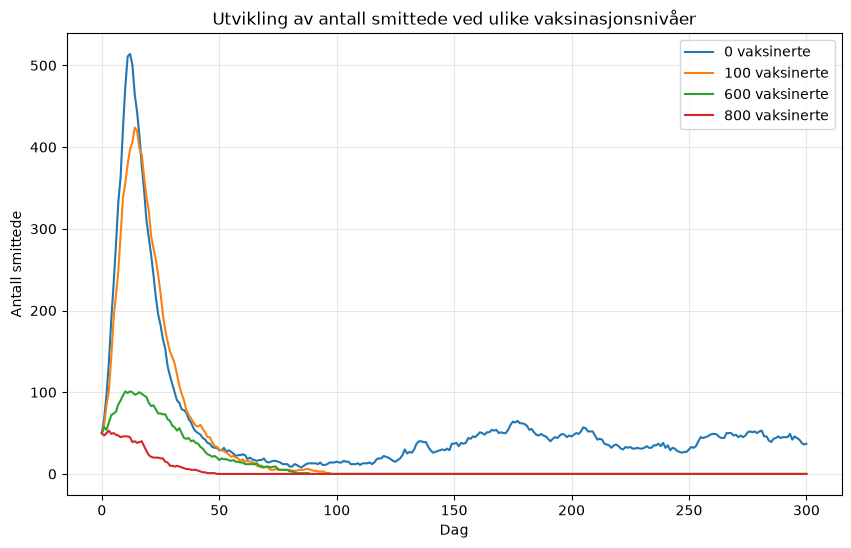

 Vaksinerte  E[maks I]              95 % KI   E[topptid]          95 % KI
          0     523.72     [522.46, 524.97]        11.86   [11.81, 11.91]
        100     439.03     [437.81, 440.26]        12.64   [12.58, 12.71]
        600      97.30       [96.48, 98.11]        15.89   [15.62, 16.16]
        800      51.36       [51.23, 51.49]         1.09     [0.97, 1.21]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

N = 1000
gamma = 0.10
alpha = 0.005
n_steps = 300
n_simulations = 1000
seed = 2026
vaccinated_cases = [0, 100, 600, 800]


def simulate_outbreak(vaccinated, rng):
    S = np.zeros(n_steps + 1, dtype=int)
    I = np.zeros(n_steps + 1, dtype=int)
    R = np.zeros(n_steps + 1, dtype=int)

    S[0] = N - vaccinated - 50
    I[0] = 50

    for n in range(n_steps):
    
        beta_n = 0.5 * I[n] / N

        new_infected = rng.binomial(S[n], beta_n)
        new_recovered = rng.binomial(I[n], gamma)
        lost_immunity = rng.binomial(R[n], alpha)

        S[n + 1] = S[n] - new_infected + lost_immunity
        I[n + 1] = I[n] + new_infected - new_recovered
        R[n + 1] = R[n] + new_recovered - lost_immunity

    return S, I, R

days = np.arange(n_steps + 1)
figure_rng = np.random.default_rng(seed + 100)
plt.figure(figsize=(10, 6))

for vaccinated in vaccinated_cases:
    _, infected, _ = simulate_outbreak(vaccinated, figure_rng)
    plt.plot(days, infected, label=f"{vaccinated} vaksinerte")

plt.xlabel("Dag")
plt.ylabel("Antall smittede")
plt.title("Utvikling av antall smittede ved ulike vaksinasjonsnivåer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


def mean_and_ci(values):
    mean = np.mean(values)
    standard_error = np.std(values, ddof=1) / np.sqrt(len(values))
    critical_value = t.ppf(0.975, df=len(values) - 1)
    margin = critical_value * standard_error
    return mean, (mean - margin, mean + margin)


results = {}

for case_number, vaccinated in enumerate(vaccinated_cases):
    rng = np.random.default_rng(seed + case_number)
    max_infected = np.zeros(n_simulations, dtype=int)
    peak_times = np.zeros(n_simulations, dtype=int)

    for sim in range(n_simulations):
        _, infected, _ = simulate_outbreak(vaccinated, rng)
        max_infected[sim] = np.max(infected)
        peak_times[sim] = np.argmax(infected)

    mean_max, ci_max = mean_and_ci(max_infected)
    mean_peak_time, ci_peak_time = mean_and_ci(peak_times)

    results[vaccinated] = {
        "mean_max": mean_max,
        "ci_max": ci_max,
        "mean_peak_time": mean_peak_time,
        "ci_peak_time": ci_peak_time,
    }


print(f"{'Vaksinerte':>11} {'E[maks I]':>10} {'95 % KI':>20} {'E[topptid]':>12} {'95 % KI':>16}")
for vaccinated in vaccinated_cases:
    result = results[vaccinated]
    max_ci = f"[{result['ci_max'][0]:.2f}, {result['ci_max'][1]:.2f}]"
    time_ci = f"[{result['ci_peak_time'][0]:.2f}, {result['ci_peak_time'][1]:.2f}]"
    print(
        f"{vaccinated:>11} {result['mean_max']:>10.2f} {max_ci:>20} "
        f"{result['mean_peak_time']:>12.2f} {time_ci:>16}"
    )

### Oppgave 1g

For å inkludere vaksinerte personer i modellen innførte vi $V$ som antall
vaksinerte. Vaksinasjon antas å gi livslang immunitet, og de vaksinerte
personene kan derfor ikke bli smittet eller gå tilbake til den mottakelige
tilstanden.

For hvert vaksinasjonsnivå startet vi med 50 smittede blant de uvaksinerte.
Starttilstanden ble derfor

$$
S_0 = N - V - 50,
\qquad
I_0 = 50,
\qquad
R_0 = 0.
$$

Vi undersøkte tilfellene

$$
V=0,\quad 100,\quad 600,\quad 800.
$$

For de uvaksinerte ble overgangene simulert på samme måte som tidligere,
med

$$
\beta_n = 0.5\frac{I_n}{N}.
$$

Antall nye smittede ble simulert som

$$
B_{SI}\sim\mathrm{Bin}(S_n,\beta_n),
$$

antall smittede som ble friske som

$$
B_{IR}\sim\mathrm{Bin}(I_n,\gamma),
$$

og antall immune som mistet immuniteten som

$$
B_{RS}\sim\mathrm{Bin}(R_n,\alpha).
$$

Figuren viser én realisering av $I_n$ for hvert vaksinasjonsnivå.
Når antallet vaksinerte øker, blir antallet mottakelige personer mindre.
Dermed blir det færre personer som kan smittes, og sykdomsutbruddet blir
generelt mindre.

Vi gjennomførte deretter 1000 simuleringer for hvert vaksinasjonsnivå og
estimerte det forventede maksimale antallet smittede og det forventede
tidspunktet for smittetoppen, på samme måte som i oppgave 1f.

Resultatene viser at det forventede maksimale antallet smittede reduseres
når flere personer vaksineres. Dette viser at vaksinasjon reduserer
alvorligheten av utbruddet ved å redusere antallet personer som er
mottakelige for smitte.